<a href="https://colab.research.google.com/github/CamFuenzalidaC/GuerrerosZ/blob/david_dev/Segunda%20_evaluacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nombre de integrantes: David Salvatierra Y Camilo Fuenzalida
seccion:003D

FUENTE DE INFORMACION: https://www.kaggle.com/datasets/anbudanadithya/spotify-music?resource=download

Contexto :  Spotify se ha posicionado como una de las aplicaciones de streaming más utilizadas a nivel mundial, recopilando millones de datos sobre canciones, artistas, géneros musicales y preferencias de los usuarios.

Gracias a esta gran cantidad de información, es posible aplicar técnicas de análisis de datos y Machine Learning para descubrir patrones ocultos dentro de la música. Variables como la popularidad de una canción, su energía, ritmo, duración, nivel acústico o danceability permiten estudiar qué características influyen en el éxito musical o cómo se relacionan los distintos géneros entre sí.

En esta investigación se tratara con un conjunto de datos de Spotify que contiene información de aproximadamente 114.000 canciones, incluyendo atributos musicales y datos relevantes como nombre del artista, álbum, género y nivel de popularidad.

El objetivo principal será analizar este dataset para :

Clasificar la energia de la cancion con el volumen de la misma ,
Poder detectar la acustica del genero y ver cual es el mas acustico
Ver la relacion entres intrumental y el volumen del genero.
Enetrenar modelos predictivos en base a la popularidad de la cancion




In [1]:

# Pandas: manipulación y análisis de datos
# NumPy: operaciones matemáticas y arreglos numéricos
# Matplotlib: creación de gráficos
# Seaborn: visualizaciones estadísticas avanzadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)

In [3]:
url = "https://raw.githubusercontent.com/CamFuenzalidaC/GuerrerosZ/ce340033c05f2b38c72ffdbfad7d39d310892e07/Spotify_Music.csv"
df = pd.read_csv(url,index_col=0)

In [4]:
df.head(5)#Visualizamos las primeras 5 filas del dataset para realizar una exploración inicial

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.tail(5) #Visualizamos las 5 ultimas filas del dataset para realizar una exploración inicial

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


Se visualizan las primeras filas del dataset con el objetivo de comprender la estructura de los datos, identificar los nombres de las columnas y analizar el tipo de información contenida en cada una. Esta exploración inicial permite obtener una mejor comprensión del conjunto de datos antes de realizar análisis más avanzados.

In [6]:
df = df.drop(columns=['track_id']) # eliminamos el tack id ya que no reprensenta  una utilidad en nuestro data set

In [7]:
df.head(5)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
df.shape # Visualizamos las dimensiones del dataset (filas y columnas) asi conoceremos el tamaño del data set

(114000, 19)

El dataset contiene 114.000 filas y 19 columnas, lo que indica que se trata de un conjunto de datos amplio y con una cantidad significativa de información. Esto permite realizar análisis estadísticos más completos y aplicar técnicas de machine learning en etapas posteriores del proyecto.

In [9]:
df.columns #mostramos los nombres de las columnas

Index(['artists', 'album_name', 'track_name', 'popularity', 'duration_ms',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

MAPEO DE DATOS:

track_id: Categórico Nominal

artists: Categórico Nominal

album_name: Categórico Nominal

track_name: Categórico Nominal

popularity: Numérico Discreto

duration_ms: Numérico Discreto

explicit: Categórico Binario

danceability: Numérico Continuo

energy: Numérico Continuo

key: Categórico Ordinal

loudness: Numérico Continuo

mode: Categórico Binario

speechiness: Numérico Continuo

acousticness: Numérico Continuo

instrumentalness: Numérico Continuo

liveness: Numérico Continuo

valence: Numérico Continuo

tempo: Numérico Continuo

time_signature: Numérico Discreto

track_genre: Categórico Nominal

Clasificación de Variables

Categórico Nominal: Categorías sin un orden o jerarquía específica.
Ejemplo: artista, nombre del álbum, género musical.

Categórico Ordinal: Categorías que siguen un orden lógico o escala.
Ejemplo: tonalidad musical representada por notas (C, D, E, F, G, A, B).

Categórico Binario: Variable con solo dos categorías posibles.
Ejemplo: explícita (Sí/No), modo musical (Mayor/Menor).

Numérico Discreto: Valores que surgen de un conteo o se expresan en números enteros.
Ejemplo: popularidad, duración en milisegundos, compás musical.

Numérico Continuo: Valores que resultan de una medición y pueden tener decimales infinitos.
Ejemplo: energía, tempo, loudness, danceability.

In [10]:
# Contamos la cantidad de canciones por cada género musical presente en el dataset
cant_cat_genero = df['track_genre'].value_counts()

print(cant_cat_genero)

# Mostramos la cantidad total de géneros únicos disponibles
print(f"Cantidad de géneros: {cant_cat_genero.count()}")

track_genre
acoustic             1000
afrobeat             1000
alt-rock             1000
alternative          1000
ambient              1000
anime                1000
black-metal          1000
bluegrass            1000
blues                1000
brazil               1000
breakbeat            1000
british              1000
cantopop             1000
chicago-house        1000
children             1000
chill                1000
classical            1000
club                 1000
comedy               1000
country              1000
dance                1000
dancehall            1000
death-metal          1000
deep-house           1000
detroit-techno       1000
disco                1000
disney               1000
drum-and-bass        1000
dub                  1000
dubstep              1000
edm                  1000
electro              1000
electronic           1000
emo                  1000
folk                 1000
forro                1000
french               1000
funk                 1000


La variable `track_genre` contiene 114 categorías diferentes de géneros musicales, lo que refleja una amplia diversidad de estilos presentes en el dataset.

In [11]:
# Calculamos la frecuencia de aparición de cada artista en el dataset
cant_cat_artists = df['artists'].value_counts()

# Mostramos los 50 artistas con mayor cantidad de registros
print(cant_cat_artists.head(50))

# Mostramos la cantidad total de artistas únicos presentes en el dataset
print(f"Cantidad de artistas únicos: {cant_cat_artists.count()}")

artists
The Beatles                       279
George Jones                      271
Stevie Wonder                     236
Linkin Park                       224
Ella Fitzgerald                   222
Prateek Kuhad                     217
Feid                              202
Chuck Berry                       190
Håkan Hellström                   183
OneRepublic                       181
The Beach Boys                    176
my little airport                 171
Elvis Presley                     169
Charlie Brown Jr.                 169
Red Hot Chili Peppers             159
Bryan Adams                       157
Scooter                           155
Daddy Yankee                      154
Arctic Monkeys                    152
BTS                               151
Norah Jones                       150
The Prophet                       145
Hank Williams                     140
Glee Cast                         139
Don Omar                          137
Vybz Kartel                       128
Los 

La variable `artists` presenta una gran cantidad de categorías únicas. Por esta razón, se mostrarán únicamente los 50 artistas con mayor frecuencia dentro del dataset para facilitar el análisis y la visualización de los resultados.

In [12]:
# Revisamos los tipos de datos de cada columna del dataset
df.dtypes

,0
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64
loudness,float64


Mediante df.dtypes se observan los tipos de datos de cada columna, lo que permite clasificar las variables y preparar correctamente el análisis de datos.

In [13]:
# Contamos la cantidad de valores nulos presentes en cada columna del dataset
df.isna().sum()

,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0
loudness,0


In [14]:
# Mostramos las filas que contienen al menos un valor nulo dentro del dataset
df[df.isnull().any(axis=1)]

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Se identifican los valores nulos presentes en el dataset con el fin de evaluar la calidad de los datos. Este proceso permite determinar si es necesario aplicar técnicas de limpieza y tratamiento de datos para evitar posibles errores o sesgos durante el análisis.

In [15]:
# Eliminamos las filas que contienen valores nulos
# para trabajar con un dataset más limpio y consistente

df = df.dropna()

In [16]:
df.isna().sum()

,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0
loudness,0


Se procede a la limpieza del dataset eliminando los valores nulos. Esto permite trabajar con datos completos y confiables, evitando inconsistencias en los resultados del análisis.

In [17]:
#veremos los tipos de datos, los nulos (no deberia haber nigun nulo)
#y los  valores unicos tambien los tipos de valores que puede tener ya sea
#categoricos o numericos
import pandas as pd

def tipo_analitico(col):
    if pd.api.types.is_numeric_dtype(col):
        return 'Numerico'
    else:
        return 'Categorico'

summary = pd.DataFrame({
    'tipo_dato': df.dtypes,
    'nulos': df.isnull().sum(),
    'n_unicos': df.nunique(),
    'tipo_analitico': df.apply(tipo_analitico)
})

summary

,tipo_dato,nulos,n_unicos,tipo_analitico
artists,object,0,31437,Categorico
album_name,object,0,46589,Categorico
track_name,object,0,73608,Categorico
popularity,int64,0,101,Numerico
duration_ms,int64,0,50696,Numerico
explicit,bool,0,2,Numerico
danceability,float64,0,1174,Numerico
energy,float64,0,2083,Numerico
key,int64,0,12,Numerico
loudness,float64,0,19480,Numerico


In [18]:
# Obtenemos un resumen estadístico de las variables numéricas,
# incluyendo promedio, desviación estándar, valores mínimos y máximos, podemos ver los posibles valores atipicos
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [19]:
# La librería `category_encoders` permite convertir variables categóricas en representaciones numéricas, facilitando su uso en algoritmos de análisis de datos y machine learning.
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.5 MB/s eta 0:00:00


In [20]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
import pandas as pd

# Aplicamos One-Hot Encoding a la variable track_genre
# ya que sus categorías no poseen un orden específico
ohe = OneHotEncoder(sparse_output=False)
genre_encoded = ohe.fit_transform(df[['track_genre']])

genre_df = pd.DataFrame(
    genre_encoded,
    columns=ohe.get_feature_names_out(['track_genre']),
    index=df.index
)

# Aplicamos Binary Encoding a la variable artists
# para reducir la cantidad de columnas generadas
be = ce.BinaryEncoder(cols=['artists'])
artists_binary = be.fit_transform(df[['artists']])

# Unimos las nuevas variables codificadas y eliminamos columnas innecesarias
cols_to_drop = ['artists', 'track_name', 'album_name', 'track_genre']

df_final = pd.concat(
    [df.drop(columns=cols_to_drop), genre_df, artists_binary],
    axis=1
)

# Visualizamos el nuevo dataset
print(df_final.head())
print(f"Total de columnas finales: {len(df_final.columns)}")

   popularity  duration_ms  explicit  danceability  energy  key  loudness  \
0          73       230666     False         0.676  0.4610    1    -6.746   
1          55       149610     False         0.420  0.1660    1   -17.235   
2          57       210826     False         0.438  0.3590    0    -9.734   
3          71       201933     False         0.266  0.0596    0   -18.515   
4          82       198853     False         0.618  0.4430    2    -9.681   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     0       0.1430        0.0322          0.000001    0.3580    0.715   
1     1       0.0763        0.9240          0.000006    0.1010    0.267   
2     1       0.0557        0.2100          0.000000    0.1170    0.120   
3     1       0.0363        0.9050          0.000071    0.1320    0.143   
4     1       0.0526        0.4690          0.000000    0.0829    0.167   

     tempo  time_signature  track_genre_acoustic  track_genre_afrobeat  \
0   87.917  

Se aplicaron técnicas de codificación a las variables categóricas para transformarlas en valores numéricos, permitiendo su utilización en modelos de análisis y machine learning.

In [21]:
# Visualizamos las primeras 50 filas del nuevo dataset
# para verificar la correcta aplicación de las técnicas de codificación
df_final.head(50)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,artists_0,artists_1,artists_2,artists_3,artists_4,artists_5,artists_6,artists_7,artists_8,artists_9,artists_10,artists_11,artists_12,artists_13,artists_14
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

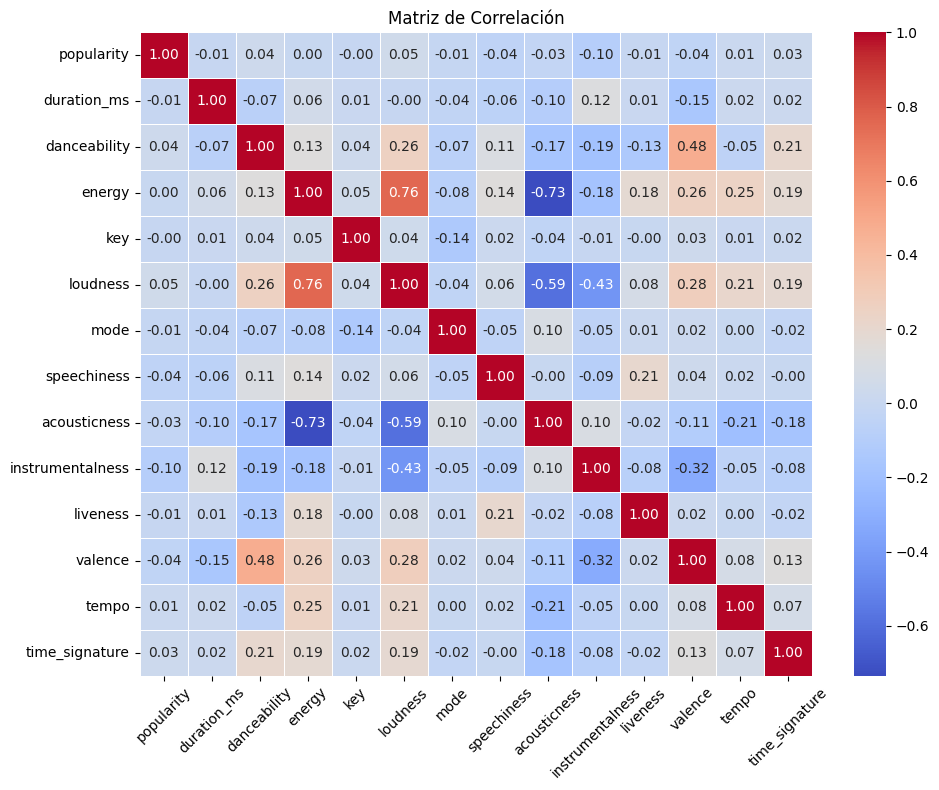

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas del dataset
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Calculamos la matriz de correlación
correlacion = df_numerico.corr()

# Visualizamos la matriz mediante un mapa de calor
plt.figure(figsize=(10,8))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Matriz de Correlación')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La matriz de correlación permite identificar relaciones entre las variables numéricas del dataset, facilitando el análisis de dependencias y patrones entre los datos.

El mapa de calor permite visualizar de forma gráfica la correlación entre variables. Los valores cercanos a 1 o -1 indican relaciones fuertes, mientras que los cercanos a 0 indican poca o ninguna relación.

### Interpretacion Final

A partir del análisis realizado, se concluye que existen algunas relaciones entre variables, aunque no todas presentan una correlación fuerte. Esto sugiere que el comportamiento de ciertas variables, como la popularidad, podría depender de múltiples factores. Este análisis será útil para la aplicación de modelos de machine learning en etapas posteriores.

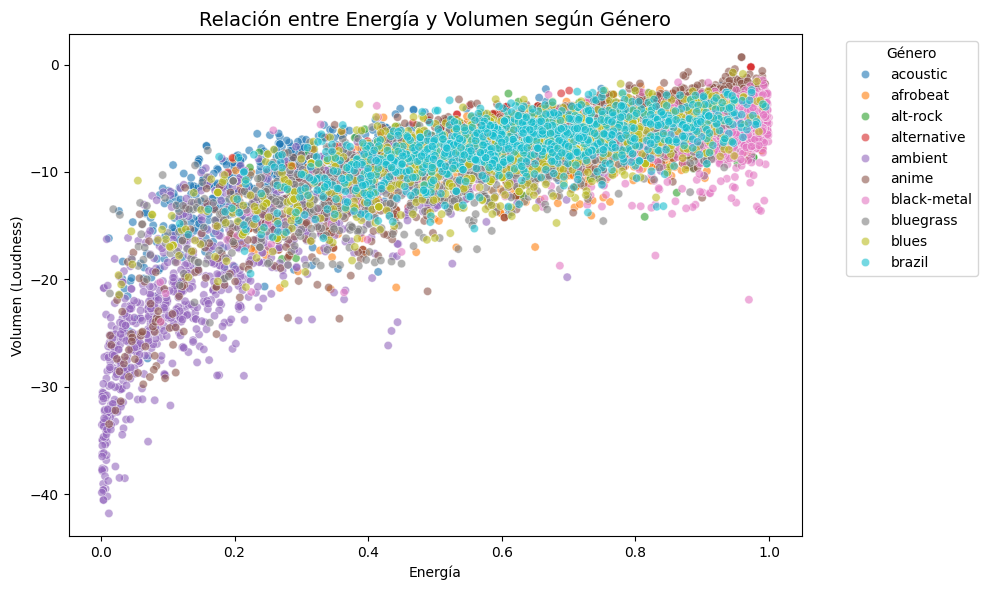

In [23]:
# Top 10 géneros más frecuentes del dataset
generos_top = df['track_genre'].value_counts().head(10).index

# Filtrar solo esos géneros
df_top10 = df[df['track_genre'].isin(generos_top)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_top10,
    x='energy',
    y='loudness',
    hue='track_genre',
    palette='tab10',
    alpha=0.6
)

plt.title('Relación entre Energía y Volumen según Género', fontsize=14)
plt.xlabel('Energía')
plt.ylabel('Volumen (Loudness)')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Se observa que ciertos géneros tienden a concentrarse en niveles más altos de energía y volumen, mientras que otros se distribuyen en zonas más bajas, lo que evidencia diferencias en las características acústicas según el tipo de música

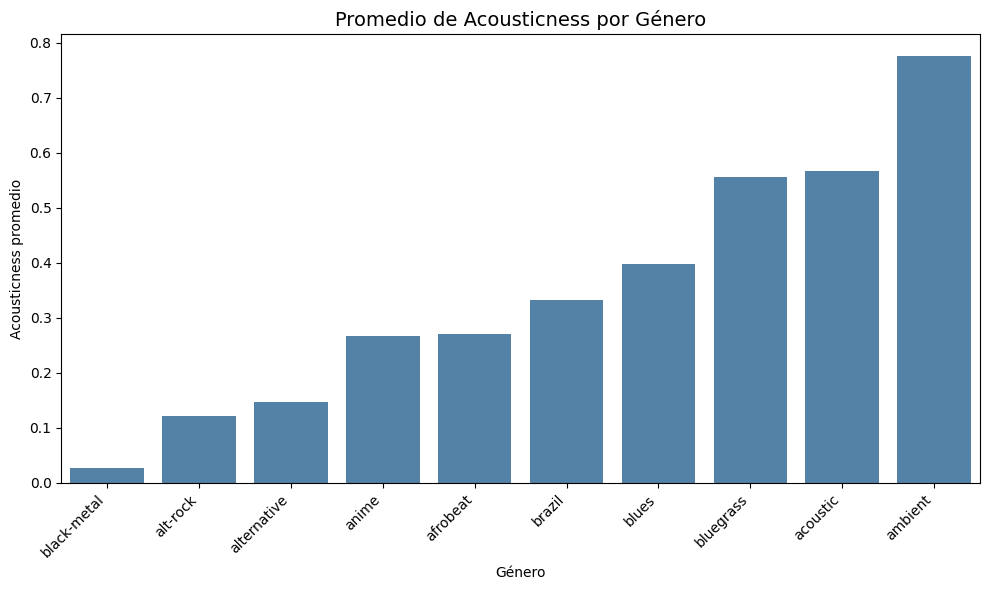

In [24]:


# 1. Obtener los 10 géneros más frecuentes
generos_top = df['track_genre'].value_counts().head(10).index
df_top10 = df[df['track_genre'].isin(generos_top)]

# 2. Calcular el promedio de acousticness por género y ordenarlo de menor a mayor
df_promedio = df_top10.groupby('track_genre')['acousticness'].mean().sort_values().reset_index()

# 3. Graficar
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_promedio,
    x='track_genre',
    y='acousticness',
    color='steelblue'  # Color similar al de tu gráfico original
)

# 4. Personalización de etiquetas (tal como los tienes en tu descripción)
plt.title('Promedio de Acousticness por Género', fontsize=14)
plt.xlabel('Género')
plt.ylabel('Acousticness promedio')

# Rotar las etiquetas del eje X para que no se amontonen
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### El gráfico muestra el nivel promedio de acousticness por género musical. Se observan diferencias claras entre géneros: aquellos con valores más altos presentan un sonido más acústico o natural, mientras que los géneros con valores más bajos tienden a ser más producidos electrónicamente. Esto evidencia que el tipo de instrumentación y producción varía según el género.

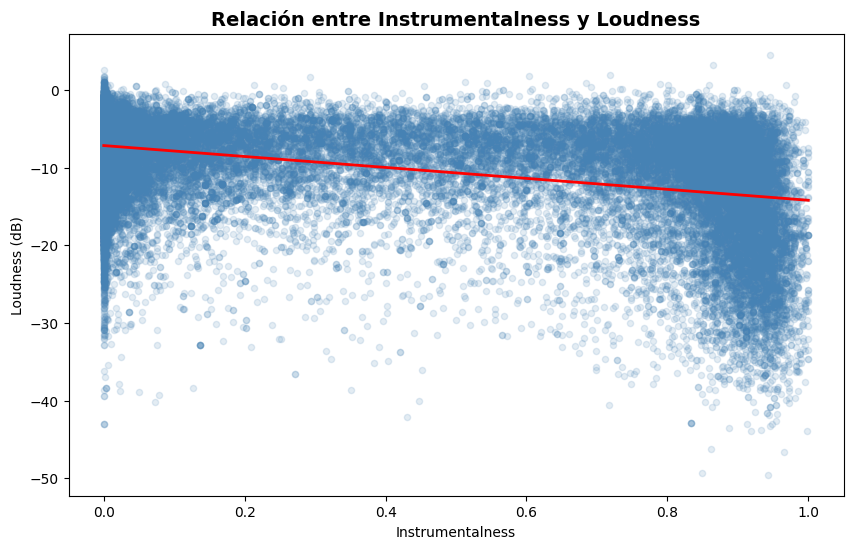

In [25]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='instrumentalness',
    y='loudness',
    scatter_kws={'alpha':0.15, 's':20, 'color':'steelblue'},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relación entre Instrumentalness y Loudness', fontsize=14, weight='bold')
plt.xlabel('Instrumentalness')
plt.ylabel('Loudness (dB)')

plt.show()

### Se observa una relación negativa moderada entre instrumentalness y loudness. Esto indica que, en promedio, las canciones con mayor contenido instrumental tienden a presentar niveles de volumen menores. Esto puede explicarse por estilos musicales más suaves o menos comprimidos en producción.

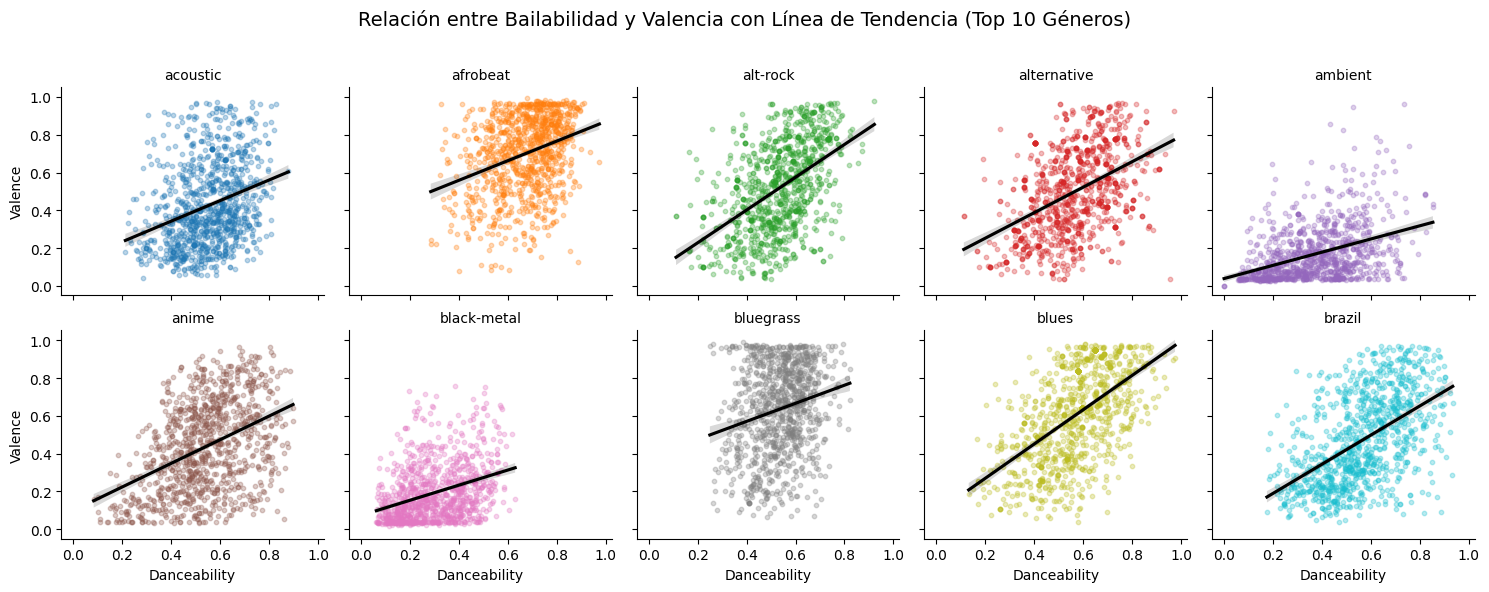

In [26]:
# Identificar los 10 géneros más frecuentes en tu columna 'track_genre'
top_10_generos = df['track_genre'].value_counts().head(10).index

# Filtrar tu dataframe original 'df' para quedarnos solo con esos 10
df_reducido = df[df['track_genre'].isin(top_10_generos)]

# Crear los subgráficos (ahora saldrán exactamente 10 cuadritos: 2 filas de 5)
g = sns.lmplot(
    data=df_reducido,
    x='danceability',
    y='valence',
    col='track_genre',
    col_wrap=5,           # Al ser 10 géneros, saldrán 5 en la primera fila y 5 en la segunda
    hue='track_genre',
    scatter_kws={'alpha': 0.3, 's': 10},
    line_kws={'color': 'black'},
    height=3,
    aspect=1
)

# Ajustar los títulos y nombres de los ejes
g.set_titles("{col_name}")
g.set_axis_labels("Danceability", "Valence")

# Ajustar el espacio para el título principal
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Relación entre Bailabilidad y Valencia con Línea de Tendencia (Top 10 Géneros)', fontsize=14)

plt.show()

El gráfico muestra que existe una relación positiva y directa entre la bailabilidad **danceability** y la positividad emocional **valence** de las canciones. Como se observa en las líneas de tendencia negras, esta pendiente ascendente se repite de forma consistente en los 10 géneros analizados. Esto demuestra que, de manera general en la música, las canciones con ritmos más bailables tienden a transmitir emociones más alegres y positivas

### **CONCLUSIÓN GENERAL**

A partir del análisis de correlación y visualización de datos, se identificaron relaciones significativas entre diversas variables musicales. Se observó una fuerte relación positiva entre energía y volumen, indicando que canciones más intensas tienden a ser más ruidosas. Asimismo, se evidenció una relación negativa entre energía y acousticness, lo que sugiere que las canciones más energéticas suelen ser menos acústicas. Por otro lado, variables como instrumentalidad y volumen no presentan una relación significativa, lo que indica independencia entre estas características. Finalmente, se observaron diferencias entre géneros musicales, evidenciando que cada uno presenta patrones propios en términos de energía, emocionalidad y producción sonora.




# ***MODELOS PREDICTIVOS***

In [27]:
#cargaremos la dependencias del modelo a tratar
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [28]:
#definiremos las variables a tratar
X = df[['danceability','energy','loudness',
        'speechiness','acousticness',
        'instrumentalness','liveness',
        'valence','tempo']]

y = df['popularity']

Se seleccionan las variables musicales que serán utilizadas para predecir la popularidad de las canciones. Además, se define la variable objetivo correspondiente al nivel de popularidad.

In [29]:
#podremos entrenar con las variables  de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

El conjunto de datos se divide en datos de entrenamiento y prueba. Esto permite entrenar el modelo y posteriormente evaluar su desempeño con información no utilizada durante el aprendizaje.

In [30]:
#creamos el modelo
modelo = RandomForestRegressor(random_state=42)

Se crea un modelo Random Forest Regressor, el cual utiliza múltiples árboles de decisión para mejorar la precisión de las predicciones y disminuir errores.

In [31]:
#entrenaremos al modelo
modelo.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

El modelo es entrenado utilizando los datos seleccionados. Durante este proceso, el algoritmo aprende patrones entre las características musicales y la popularidad de las canciones.

In [32]:
#generamos una prediccion para el modelo
predicciones = modelo.predict(X_test)

Una vez entrenado el modelo, se generan predicciones sobre el conjunto de prueba para estimar la popularidad de las canciones.

In [33]:
#crearemos resultados para dpeues agregaron  a la info
resultados = X_test.copy()
# agregar información original
resultados['track_name'] = df.loc[X_test.index, 'track_name']
resultados['artists'] = df.loc[X_test.index, 'artists']

# agregar valores reales y predichos
resultados['popularidad_real'] = y_test
resultados['popularidad_predicha'] = predicciones


Se crea una tabla que compara la popularidad real y la popularidad predicha por el modelo, incluyendo además el nombre de la canción y el artista.

In [34]:
#tendremos los resultados finales
resultados_finales = resultados[['track_name',
                                 'artists',
                                 'popularidad_real',
                                 'popularidad_predicha']].copy()

Se filtran únicamente las columnas más relevantes para facilitar la interpretación y visualización de los resultados obtenidos.

In [35]:
#observaremos la popularidad de la cancion y del artista , comparando asi la poularidad real y la predicha
resultados_finales['popularidad_predicha'] = resultados_finales[
    'popularidad_predicha'
].round(2)

resultados_finales.head(10)

,track_name,artists,popularidad_real,popularidad_predicha
113186,No Other Name,Hillsong Worship,50,45.04
42819,Failed Organum,Internal Rot,11,12.56
59311,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,0,18.79
90417,It's Only Make Believe,Billy Fury,34,36.35
61000,月の大きさ,Nogizaka46,57,33.32
96815,"Jah Jah Revolta, Pt. 2",BaianaSystem,38,37.99
18939,Please Stop Communicating,Joe DeRosa,21,24.26
72760,A Form of Protest,Cane Hill,54,32.58
25788,I'm Ready - Radio Edit,Kano,29,30.53
87169,Proibida Pra Mim (Grazon) - Ao Vivo,Charlie Brown Jr.,48,44.48


Se muestran ejemplos de canciones junto a sus valores reales y predichos, permitiendo observar qué tan cercanas son las estimaciones realizadas.

In [36]:
# Evaluar rendimiento del modelo
puntaje_modelo = r2_score(y_test, predicciones)
error_promedio = mean_absolute_error(y_test, predicciones)

# Mostraresmos los resultados del modelo
print(f"Capacidad predictiva del modelo (R2): {puntaje_modelo:.2f}")
print(f"Error promedio de predicción: {error_promedio:.2f}")

Capacidad predictiva del modelo (R2): 0.54
Error promedio de predicción: 10.78


El modelo logró una capacidad predictiva de 0.54 en la métrica R², indicando un buen desempeño en la predicción de popularidad musical. Además, presentó un error promedio de 10.78 puntos respecto a los valores reales.


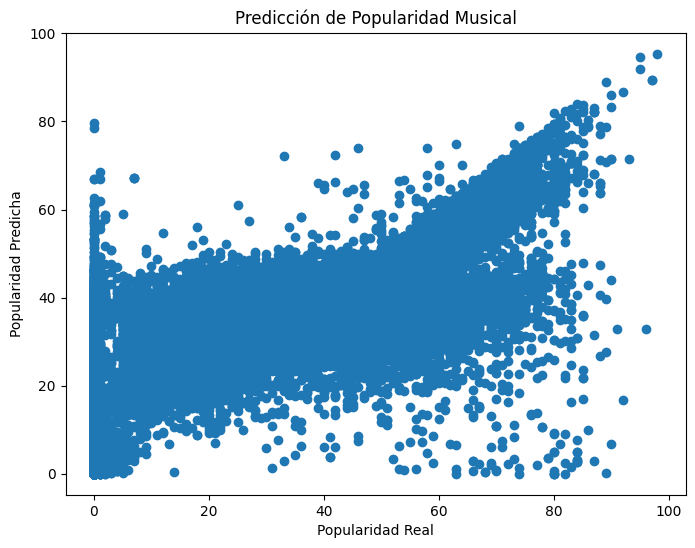

In [37]:
#en este grafico podremos comparar la popularidad predicha y popularidad real
#dentro de popularidad.

plt.figure(figsize=(8,6))

plt.scatter(y_test, predicciones)

plt.xlabel("Popularidad Real")
plt.ylabel("Popularidad Predicha")
plt.title("Predicción de Popularidad Musical")

plt.show()

Se genera un gráfico de dispersión para visualizar la relación entre los valores reales y los valores estimados por el modelo predictivo.

*MODELO KNN*



El modelo KNN predesira  la popularidad buscando canciones “parecidas”

“Si canciones similares tienen popularidad 40 y 50, esta probablemente tendrá ~45”.

In [38]:
#Importaremos las dependencias que usaremos
from sklearn.neighbors import KNeighborsRegressor

In [39]:
#crearemos un modelo
modelo_knn = KNeighborsRegressor(n_neighbors=5)

Se construye un modelo KNN utilizando una cantidad determinada de vecinos cercanos para realizar estimaciones de popularidad.

In [40]:
#ahora entrenaremos
modelo_knn.fit(X_train, y_train)

KNeighborsRegressor()

El modelo KNN es entrenado utilizando los datos de entrenamiento, permitiendo identificar patrones y similitudes entre canciones.

In [41]:
#ahora podremos predecir
predicciones_knn = modelo_knn.predict(X_test)

El modelo KNN genera predicciones utilizando los datos de prueba para estimar la popularidad musical.

In [42]:
#ahora podremos evaluar el resultado
r2_knn = r2_score(y_test, predicciones_knn)
mae_knn = mean_absolute_error(y_test, predicciones_knn)

print(f"R2 KNN: {r2_knn:.2f}")
print(f"Error promedio KNN: {mae_knn:.2f}")

R2 KNN: 0.15
Error promedio KNN: 15.77


Aunque el modelo presenta un buen desempeño, aún existen factores externos no considerados en el dataset, como tendencias virales, marketing o fama del artista, que también influyen en la popularidad musical.

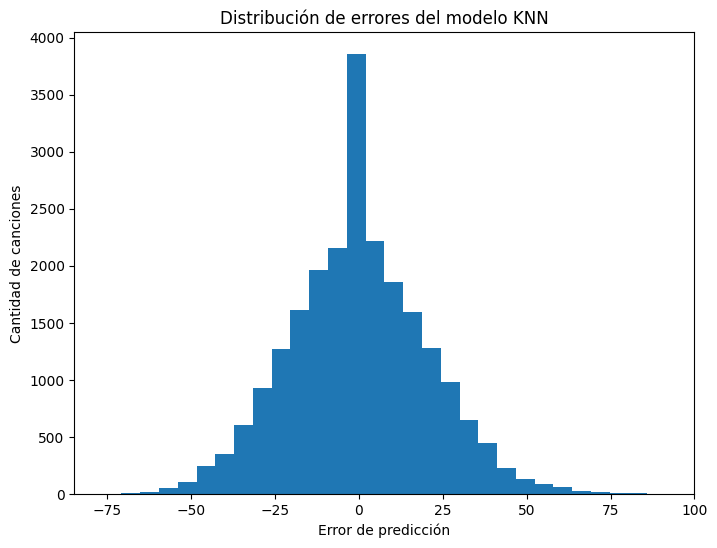

In [43]:
errores_knn = y_test - predicciones_knn

plt.figure(figsize=(8,6))

plt.hist(errores_knn, bins=30)

plt.xlabel("Error de predicción")
plt.ylabel("Cantidad de canciones")
plt.title("Distribución de errores del modelo KNN")

plt.show()

Se genera un histograma que permite visualizar la distribución de errores entre la popularidad real y la popularidad predicha, facilitando el análisis del comportamiento del modelo.

*MODELO DE ARBOL DE DISICIONES*

El modelo Árbol de Decisión predice la popularidad dividiendo el espacio de características en regiones mediante preguntas sucesivas:

"Si la energía > 0.7 Y el loudness > -5, la popularidad estimada es ~65".

Es fácil de interpretar visualmente y permite entender qué variables son más importantes en la predicción.

In [44]:
# Importaremos las dependencias del Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

In [45]:
# Crearemos el modelo con profundidad máxima para evitar sobreajuste
modelo_dt = DecisionTreeRegressor(max_depth=5, random_state=42)



Se construye un Árbol de Decisión con profundidad máxima de 5 niveles. Limitar la profundidad evita el sobreajuste (overfitting), lo que permite que el modelo generalice mejor a datos nuevos.



In [46]:
# Entrenamos el modelo con los datos de entrenamiento
modelo_dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

El modelo Árbol de Decisión es entrenado utilizando los datos de entrenamiento, aprendiendo reglas de decisión basadas en las características musicales para predecir la popularidad.

In [47]:
# Generamos predicciones sobre el conjunto de prueba
predicciones_dt = modelo_dt.predict(X_test)

El modelo genera predicciones sobre el conjunto de prueba aplicando las reglas aprendidas durante el entrenamiento.

In [48]:
# Evaluamos el rendimiento del modelo
r2_dt = r2_score(y_test, predicciones_dt)
mae_dt = mean_absolute_error(y_test, predicciones_dt)

print(f"R2 Árbol de Decisión: {r2_dt:.2f}")
print(f"Error promedio Árbol de Decisión: {mae_dt:.2f}")

R2 Árbol de Decisión: 0.04
Error promedio Árbol de Decisión: 18.06


Se evalúa el modelo con las métricas R² y error promedio (MAE). El R² indica qué proporción de la variabilidad en popularidad explica el modelo, mientras que el MAE muestra cuántos puntos se aleja en promedio la predicción del valor real.

/tmp/ipykernel_2217/2957487632.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_ordenadas.values, y=importancias_ordenadas.index, palette='viridis')


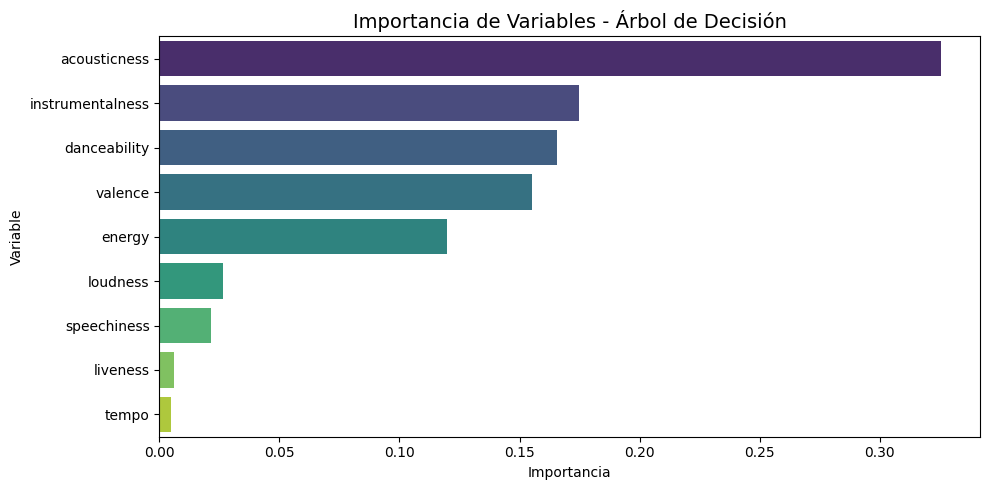

In [49]:
# Visualizamos la importancia de cada variable para el modelo
importancias = pd.Series(modelo_dt.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importancias_ordenadas.values, y=importancias_ordenadas.index, palette='viridis')
plt.title('Importancia de Variables - Árbol de Decisión', fontsize=14)
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

Se visualiza la importancia de cada variable musical en la predicción de popularidad. Las variables con mayor importancia son las que el árbol utiliza con más frecuencia para dividir los datos, siendo los factores más influyentes según el modelo.

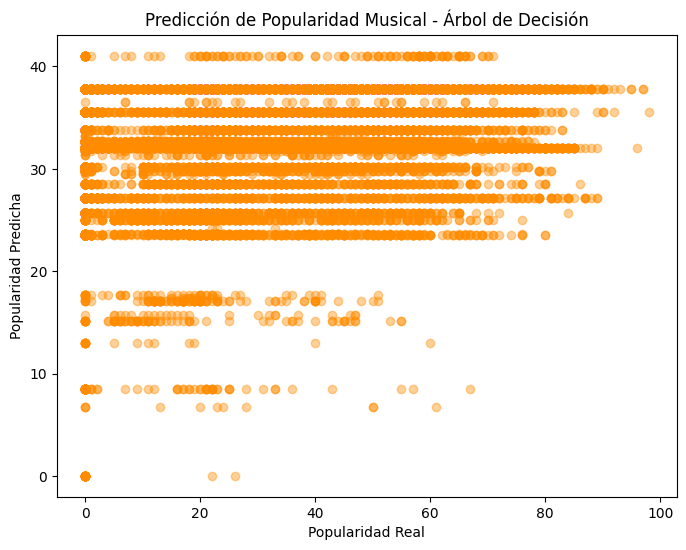

In [50]:
# Comparamos la popularidad real vs predicha
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predicciones_dt, alpha=0.4, color='darkorange')

plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title('Predicción de Popularidad Musical - Árbol de Decisión')

plt.show()

Se genera un gráfico de dispersión para comparar visualmente los valores reales y los estimados por el Árbol de Decisión, permitiendo evaluar qué tan bien se ajusta el modelo a los datos de prueba.

In [51]:
# Comparación final de los tres modelos
print('=== COMPARACIÓN DE MODELOS ===')
print(f'Random Forest  -> R2: {puntaje_modelo:.2f} | MAE: {error_promedio:.2f}')
print(f'KNN            -> R2: {r2_knn:.2f} | MAE: {mae_knn:.2f}')
print(f'Árbol Decisión -> R2: {r2_dt:.2f} | MAE: {mae_dt:.2f}')

=== COMPARACIÓN DE MODELOS ===
Random Forest  -> R2: 0.54 | MAE: 10.78
KNN            -> R2: 0.15 | MAE: 15.77
Árbol Decisión -> R2: 0.04 | MAE: 18.06


### **Conclusión Árbol de Decisión**

El modelo Árbol de Decisión ofrece una alternativa interpretable para predecir la popularidad musical. A diferencia de Random Forest y KNN, permite visualizar exactamente qué reglas de decisión utiliza el modelo, facilitando su comprensión.

Comparando los tres modelos entrenados:
- **Random Forest** suele obtener el mejor desempeño al combinar múltiples árboles, reduciendo el error.
- **KNN** es sencillo pero sensible a la escala de las variables.
- **Árbol de Decisión** es el más interpretable, aunque puede ser menos preciso si los datos tienen relaciones complejas.

En conjunto, los tres modelos demuestran que características como la energía, danceability y loudness son relevantes para estimar la popularidad de una canción.